# Ball Falling to earth real time

In [1]:
from vpython import *
scene = canvas()

scene.autoscale = False

# Create floor
floor = box(pos=vec(0, -10, 0), size=vec(10, 0.1, 10), color=color.green)


ball_start_y = 3  
ball = sphere(pos=vec(0, ball_start_y, 0), radius=0.3, color=color.yellow, make_trail=True)
h0 = ball_start_y - floor.pos.y  # distance (height)
velocity = vec(0, 0, 0)  
g = 9.8 
dt = 0.01  
# used to track time
t = 0

while ball.pos.y > floor.pos.y + ball.radius:  
    rate(100)  # change if too fast 100 = real time
    velocity = velocity + vec(0, -g, 0) * dt  
    ball.pos = ball.pos + velocity * dt
    t = t + dt

# Results
print(f"Time to hit floor: {t:.3f} seconds")
print(f"Final velocity: {abs(velocity.y):.3f} m/s")

# Verification
expected_t = sqrt(2 * h0 / g)
expected_v = sqrt(2 * g * h0)


print(f"Expected time (physics): {expected_t:.3f} seconds")
print(f"Expected velocity (physics): {expected_v:.3f} m/s")



C:\Users\there\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Time to hit floor: 1.610 seconds
Final velocity: 15.778 m/s
Expected time (physics): 1.629 seconds
Expected velocity (physics): 15.962 m/s


My initial assumptions was this is using the metric system and that gravity is 9.8 m/s^2. Additionally there is a floor at -10 m. Time step size is 0.01 so it can run as close as it can to real time.

# Ball Bouncing Perfect elasticity

In [2]:
from vpython import *
scene = canvas()

scene.autoscale = False

floor = box(pos=vec(0, -10, 0), size=vec(10, 0.1, 10), color=color.green)


ball_start_y = 3  
ball = sphere(pos=vec(0, ball_start_y, 0), radius=0.3, color=color.yellow, make_trail=True)
h0 = ball_start_y - floor.pos.y  # distance (height)
velocity = vec(0, 0, 0)  
g = 9.8 
dt = 0.01  
# used to track time
t = 0

while t < 10: #bounces for 10 seconds
    rate(100)  # change if too fast 100 = real time

    velocity = velocity + vec(0, -g, 0) * dt  
    ball.pos = ball.pos + velocity * dt

    if ball.pos.y <= floor.pos.y + ball.radius:
        ball.pos.y = floor.pos.y + ball.radius
        velocity.y = -velocity.y

    t = t + dt
        
    

<IPython.core.display.Javascript object>

Using Quetion 1 as a template I already knew that the ball simiulation's physics was fine going down, all I had to do was reverse the velocity when it hit the ground. With that the same assumptions as 1 + the time the simulation goes on for is 10 seconds. Step size is same as well.

# Ball firing from cannon

In [19]:
from vpython import *
scene = canvas()

scene.autoscale = False

ground = box(pos=vec(25, -0.5, 0), size=vec(50,0.1,10), color=color.green)

ball1 = sphere(pos=vec(0, 0, 0), radius=0.3, color=color.yellow, make_trail=True)
ball2 = sphere(pos=vec(0, 0, 0), radius=0.3, color=color.blue, make_trail=True)
ball3 = sphere(pos=vec(0, 0, 0), radius=0.3, color=color.red, make_trail=True)
velocity = vec(0, 0, 0)  
g = 9.8 
dt = 0.01  
# used to track time
t = 0
theta1 = 45
theta2 = 15
theta3 = 85

v0 = 20

#convert angles to rads
theta1 = radians(theta1)
theta2 = radians(theta2)
theta3 = radians(theta3)

velocity1 = vec(v0 * cos(theta1), v0 * sin(theta1), 0)
velocity2 = vec(v0 * cos(theta2), v0 * sin(theta2), 0)
velocity3 = vec(v0 * cos(theta3), v0 * sin(theta3), 0)

while t < 5:
    rate(100)

    if ball1.pos.y >= ground.pos.y + ball1.radius:
        velocity1 = velocity1 + vec(0, -g, 0) * dt
        ball1.pos = ball1.pos + velocity1 * dt

    if ball2.pos.y >= ground.pos.y + ball2.radius:
        velocity2 = velocity2 + vec(0, -g, 0) * dt
        ball2.pos = ball2.pos + velocity2 * dt

    if ball3.pos.y >= ground.pos.y + ball3.radius:
        velocity3 = velocity3 + vec(0, -g, 0) * dt
        ball3.pos = ball3.pos + velocity3 * dt

    t = t + dt


# used distance eqn: X = (v0^2 * sin(2*theta))/g
print(f"\nBall 1:")
print(f"  Simulated range: {ball1.pos.x:.2f} m")
print(f"  Actual range: {(v0**2 * sin(2*theta1)) / g:.2f} m")

print(f"\nBall 2:")
print(f"  Simulated range: {ball2.pos.x:.2f} m")
print(f"  Actual range: {(v0**2 * sin(2*theta2)) / g:.2f} m")

print(f"\nBall 3:")
print(f"  Simulated range: {ball3.pos.x:.2f} m")
print(f"  Actual range: {(v0**2 * sin(2*theta3)) / g:.2f} m")

<IPython.core.display.Javascript object>


Ball 1:
  Simulated range: 41.01 m
  Actual range: 40.82 m

Ball 2:
  Simulated range: 21.06 m
  Actual range: 20.41 m

Ball 3:
  Simulated range: 7.09 m
  Actual range: 7.09 m


Same time step as before, initial velocity is 20 m/s, gravity is gravity, the three different balls launched with different angles theta1 = 45, theta2= 15, theta3 = 85. I verified using the horizontal distance traveled before the balls hit the ground. With this I can see that the simulation is close to the actual or calculated range/distance. Also doing this, and figured it would be obvious, but the 45 degree angle traveled the furthest around 41 m.

# Ball falling revisted

In [21]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.8 MB 5.6 MB/s eta 0:00:02
   ------------ --------------------------- 2.4/7.8 MB 6.4 MB/s eta 0:00:01
   ------------------------ --------------- 4.7/7.8 MB 7.9 MB/s eta 0:00:01
   -------------------------------------- - 7.6/7.8 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 9.1 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------- -------------------- 3.4/7.0 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------  6.8/7.0 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 14.8 MB/s  0:00:0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

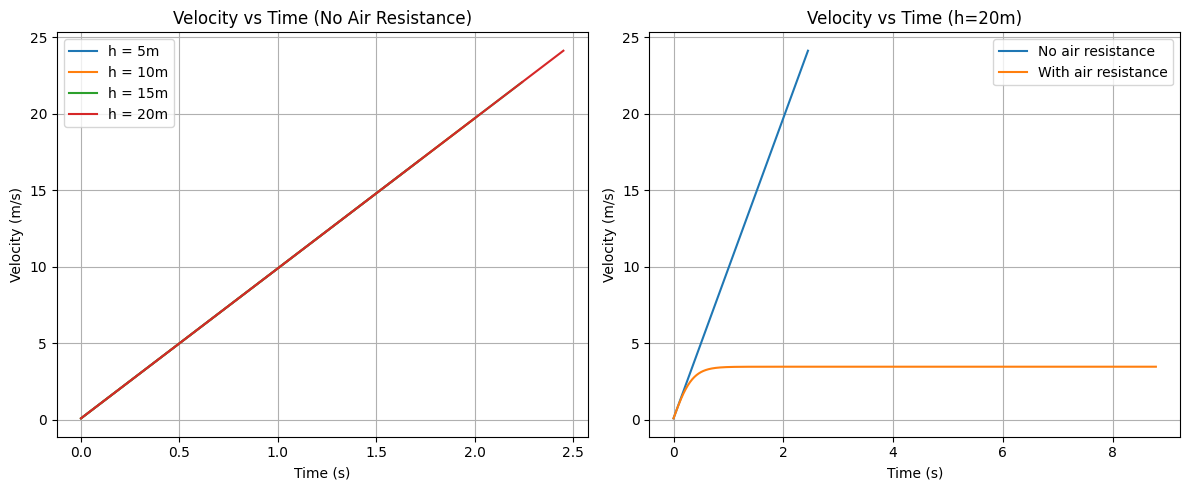

Max velocity without air resistance (h=20m): 24.11 m/s
Max velocity with air resistance (h=20m): 3.47 m/s


In [25]:
from vpython import *
import matplotlib.pyplot as plt

def simulate_fall(height, with_air_resistance=False):
    scene = canvas()
    scene.autoscale = False
    
    floor = box(pos=vec(0, -10, 0), size=vec(10, 0.1, 10), color=color.green)
    ball = sphere(pos=vec(0, height, 0), radius=0.3, color=color.yellow, make_trail=True)
    
    velocity = vec(0, 0, 0)
    g = 9.8
    dt = 0.01
    t = 0
    
    time_data = []
    velocity_data = []

    # https://www.google.com/search?q=air+resistance+equation&rlz=1C1VDKB_enUS1073US1073&oq=air+re&gs_lcrp=EgZjaHJvbWUqBwgCEAAYgAQyBggAEEUYOTIKCAEQABixAxiABDIHCAIQABiABDIHCAMQABiABDIHCAQQABiABDINCAUQLhjHARjRAxiABDIHCAYQABiABDIHCAcQABiABDIHCAgQABiABDIHCAkQABiABNIBCDMyNzdqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8
    # Air resistance parameters Drag equation: F_d = 0.5 * C_d * ρ * A * v^2
    C_d = 0.47  # Drag coefficient for sphere
    rho = 1.225  # Air density kg/m^3
    A = 3.14159 * (0.3**2)  # Cross-sectional area
    m = 0.1  # Mass of ball in kg
    
    while ball.pos.y > floor.pos.y + ball.radius:
        rate(100)
        
        if with_air_resistance:
            v_mag = mag(velocity)
            if v_mag > 0:
                F_drag = 0.5 * C_d * rho * A * v_mag**2
                drag_acc = (F_drag / m) * (-velocity / v_mag)
                velocity = velocity + (vec(0, -g, 0) + drag_acc) * dt
            else:
                velocity = velocity + vec(0, -g, 0) * dt
        else:
            velocity = velocity + vec(0, -g, 0) * dt
        
        ball.pos = ball.pos + velocity * dt
        
        time_data.append(t)
        velocity_data.append(abs(velocity.y))
        
        t = t + dt
    
    
    return time_data, velocity_data

# Simulate different heights without air resistance
heights = [5, 10, 15, 20]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for h in heights:
    time, vel = simulate_fall(h, with_air_resistance=False)
    plt.plot(time, vel, label=f'h = {h}m')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time (No Air Resistance)')
plt.legend()
plt.grid(True)

# Compare with and without air resistance for h=20m
plt.subplot(1, 2, 2)
time_no_air, vel_no_air = simulate_fall(20, with_air_resistance=False)
time_air, vel_air = simulate_fall(20, with_air_resistance=True)
plt.plot(time_no_air, vel_no_air, label='No air resistance')
plt.plot(time_air, vel_air, label='With air resistance')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Velocity vs Time (h=20m)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Max velocity without air resistance (h=20m): {max(vel_no_air):.2f} m/s")
print(f"Max velocity with air resistance (h=20m): {max(vel_air):.2f} m/s")

Without air restistance, the velocity increases due to gravity, however with air resistance, the velocity remains mostly the same once it reached a certain velocity. COnstants I choose for air restistance: 
    C_d = 0.47  # Drag coefficient for sphere
    rho = 1.225  # Air density kg/m^3
    A = 3.14159 * (0.3**2)  # Cross-sectional area
    m = 0.1  # Mass of ball in kg
Everything else stayed the same just like the other questions including step sizes

# Ball bouncing revisted

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

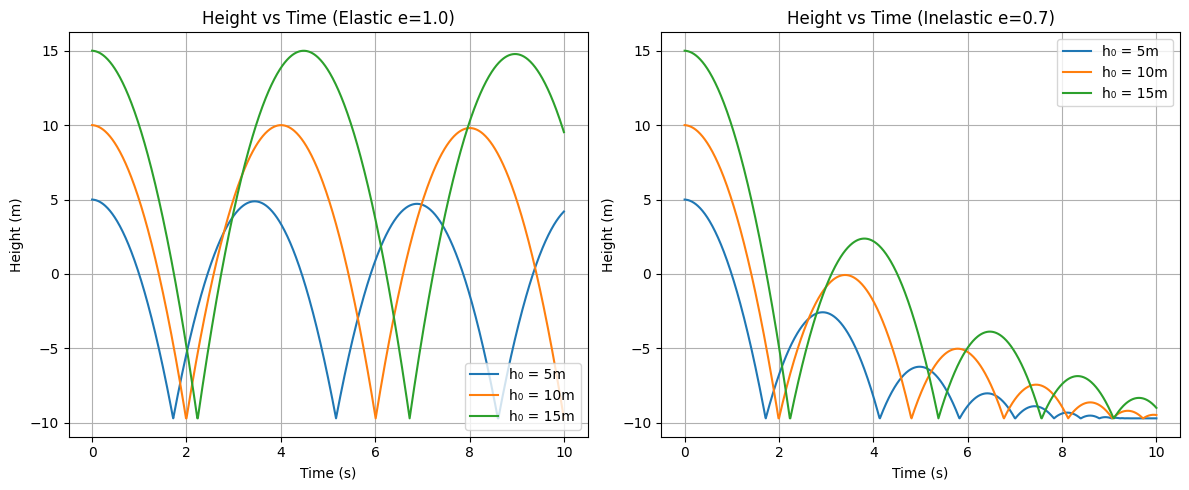

In [2]:
from vpython import *
import matplotlib.pyplot as plt

def simulate_bounce(height, elasticity=1.0):
    scene = canvas()
    scene.autoscale = False
    floor = box(pos=vec(0, -10, 0), size=vec(10, 0.1, 10), color=color.green)
    ball = sphere(pos=vec(0, height, 0), radius=0.3, color=color.yellow, make_trail=True)
    
    velocity = vec(0, 0, 0)  
    g = 9.8 
    dt = 0.01  
    # used to track time
    t = 0
    
    time_data = []
    height_data = []
    
    while t < 10: #bounce for 10 seconds
        rate(100) #change if too fast 100 = real time
        velocity = velocity + vec(0, -g, 0) * dt  
        ball.pos = ball.pos + velocity * dt
        
        if ball.pos.y <= floor.pos.y + ball.radius:
            ball.pos.y = floor.pos.y + ball.radius
            velocity.y = -velocity.y * elasticity #elasticity < 1 = inelastic collision
        #https://www.google.com/search?q=inelastic+collision+equation&rlz=1C1VDKB_enUS1073US1073&oq=inelastic+coll&gs_lcrp=EgZjaHJvbWUqDAgAEAAYQxiABBiKBTIMCAAQABhDGIAEGIoFMhAIARAAGJECGLEDGIAEGIoFMg0IAhAAGJECGIAEGIoFMg0IAxAAGJECGIAEGIoFMgcIBBAAGIAEMgcIBRAAGIAEMgcIBhAAGIAEMgwIBxAAGBQYhwIYgAQyBwgIEAAYgAQyBwgJEAAYgATSAQgzMTEwajBqOagCALACAA&sourceid=chrome&ie=UTF-8
        time_data.append(t)
        height_data.append(ball.pos.y)
        t = t + dt
    
    del scene
    return time_data, height_data

heights = [5, 10, 15]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for h in heights:
    time, height = simulate_bounce(h, elasticity=1.0)
    plt.plot(time, height, label=f'h₀ = {h}m')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Height vs Time (Elastic e=1.0)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for h in heights:
    time, height = simulate_bounce(h, elasticity=0.7)
    plt.plot(time, height, label=f'h₀ = {h}m')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Height vs Time (Inelastic e=0.7)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



Elastic coefficient is 0.7, same other constants and step as before. The highest height managed to bounce longer than the smaller heights while smallest height straightened out quicker.